# Your first experiment

A tutorial for someone who has just found OpenCDaRR and has read nothing else. By the end you will
have run a complete study and — more importantly — know how to read the answer, including the parts
that are easy to misread.

## What the library is for

Two aircraft are heading for the same piece of sky. Each carries software that is supposed to notice,
do something about it, and then get back on course. The question this library exists to answer is:
**how often does that software fail, and how badly?**

The difficulty is that the aircraft do not have perfect information. Each measures its own position
with a receiver that is off by some metres, broadcasts that measurement over a radio link that
sometimes drops it, and decides what to do from a picture of the other aircraft that is slightly
stale and slightly wrong. So the same encounter, flown twice, does not come out the same. Safety is
a **probability**, not a yes or no — and measuring a probability means running the encounter many
times.

That is what an experiment is here: run the same situation many times, count what happened.

## Five words you will need

| word | what it means |
|---|---|
| **protected zone** | a circle around each aircraft that nothing else should enter — 50 m here |
| **loss of separation** | something entered it. The bad outcome we are counting |
| **conflict** | the aircraft are heading for a loss of separation if nobody acts |
| **resolution** | the manoeuvre that avoids it |
| **encounter** | one run: two aircraft, one conflict, start to finish |

Everything else you can pick up as you go.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    MC,                # the "run it many times and count" estimator
    MVP,               # an avoidance algorithm
    Agent,             # one aircraft: where it is, plus what flies it
    Fixed,             # "hold this parameter still"
    GnssNavigation,    # a position sensor that makes mistakes
    M600,              # a DJI M600's speed and acceleration limits
    Methods,           # the bundle of algorithms a run uses
    PastCPA,           # decides when it is safe to stop avoiding
    StateBased,        # decides whether there is a conflict
    Sweep,             # "vary this parameter"
    create_aircraft,
    create_conflict,
    estimate_ipr,      # run many encounters, count losses
    generator,
    plot_pairwise,
    root_seed_sequence,
    run_experiment,    # run many *conditions*, tabulate
    run_fleet,         # run one encounter
    spawn,
    wilson_interval,
)
from opencdarr.config import load_config
from opencdarr.geo import qdrdist

RPZ = 50.0        # protected zone radius, metres
print("ready")

ready


## Step 1: one encounter

Start with the smallest thing that works. Put an aircraft somewhere, then ask the library to place a
second one **on a collision course with it**:

In [2]:
own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0)

intr = create_conflict(
    own,
    intr_id="INT",
    dpsi=45.0,      # it crosses at 45 degrees to us
    dcpa=0.0,       # aimed dead-on: without avoidance they would collide
    tlos=90.0,      # separation would be lost 90 seconds from now
    rpz=RPZ,
)

print(f"OWN  heading {own.trk:>5.1f}°  at {own.gs} m/s")
print(f"INT  heading {intr.trk:>5.1f}°  at {intr.gs} m/s")
print(f"they start {qdrdist(own.lat, own.lon, intr.lat, intr.lon)[1]:.0f} m apart")

OWN  heading   0.0°  at 10.0 m/s
INT  heading  45.0°  at 10.0 m/s
they start 739 m apart


Now fly them. `run_fleet` takes a list of aircraft plus the algorithms that decide what they do, and
runs until the encounter is over.

Those algorithms are the interesting part, and each is swappable:

- **`StateBased`** looks ahead and predicts whether the two will come too close.
- **`MVP`** works out the avoidance manoeuvre when it does.
- **`PastCPA`** decides when the danger has passed and it is safe to resume.

was there a conflict?     True
was separation lost?      False
closest they ever came:   103.4 m   (protected zone is 50 m)


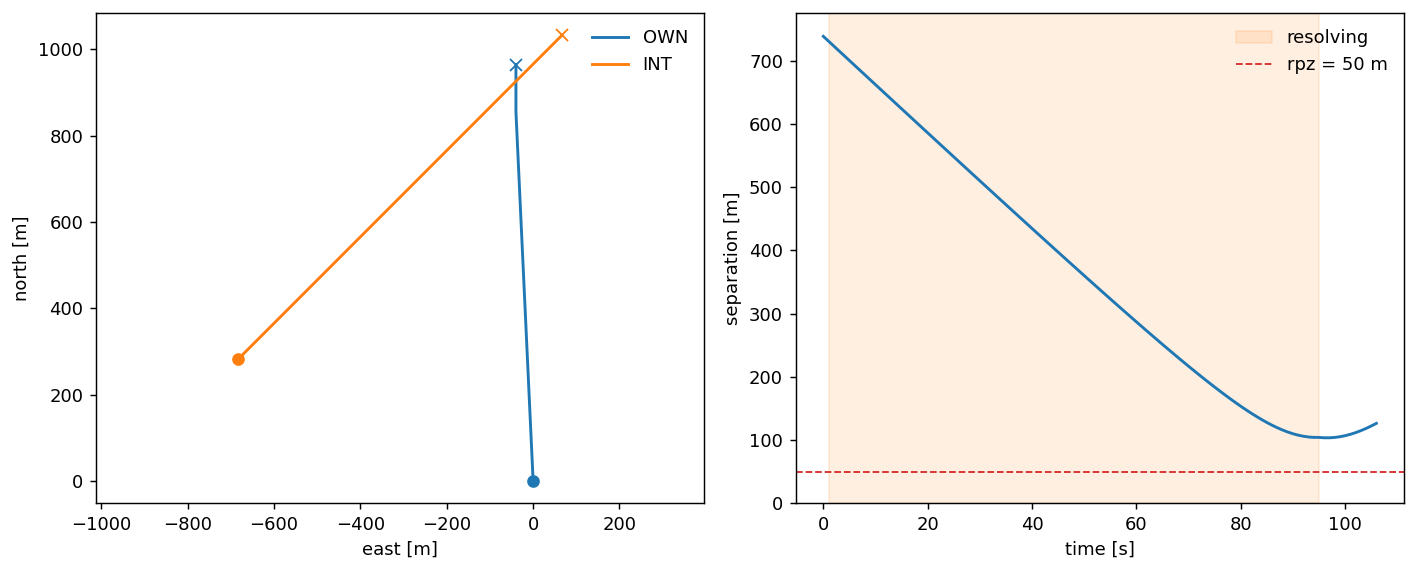

In [3]:
outcome = run_fleet(
    [Agent(own, M600), Agent(intr, M600)],
    rpz=RPZ,
    t_lookahead=120.0,     # predict 2 minutes ahead
    dt=1.0,                # simulate in 1-second steps
    detector=StateBased(),
    resolver=MVP(margin=1.05),
    recovery=PastCPA(),
    t_max=600.0,
    record=True,           # keep the whole trajectory so we can plot it
)

print(f"was there a conflict?     {outcome.conflict}")
print(f"was separation lost?      {outcome.los}")
print(f"closest they ever came:   {outcome.min_sep:.1f} m   (protected zone is {RPZ:.0f} m)")

fig = plot_pairwise(outcome, rpz=RPZ)

The left panel is the path each aircraft flew; the right is how far apart they were over time, with
the protected zone marked. They saw each other, both moved, and the gap never came close to 50 m.

**This was a perfect-information run.** Neither aircraft made any measurement error, so both knew
exactly where the other was. Run it again and you get an identical result — there is nothing random
in it.

## Step 2: nobody knows exactly where they are

Real aircraft measure their own position and get it slightly wrong. Add that, and the picture
changes.

Two things are needed, and both matter. The aircraft has to *have* an accuracy — `pos_ci95=20` means
"95% of my position fixes land within 20 m of the truth" — and the run needs a **navigation model**
to actually draw an error from that number. Without the model, the accuracy is just an unused
number sitting on the aircraft.

perfect information:  closest approach  103.4 m,  separation lost: False
with sensor error:    closest approach  175.9 m,  separation lost: False


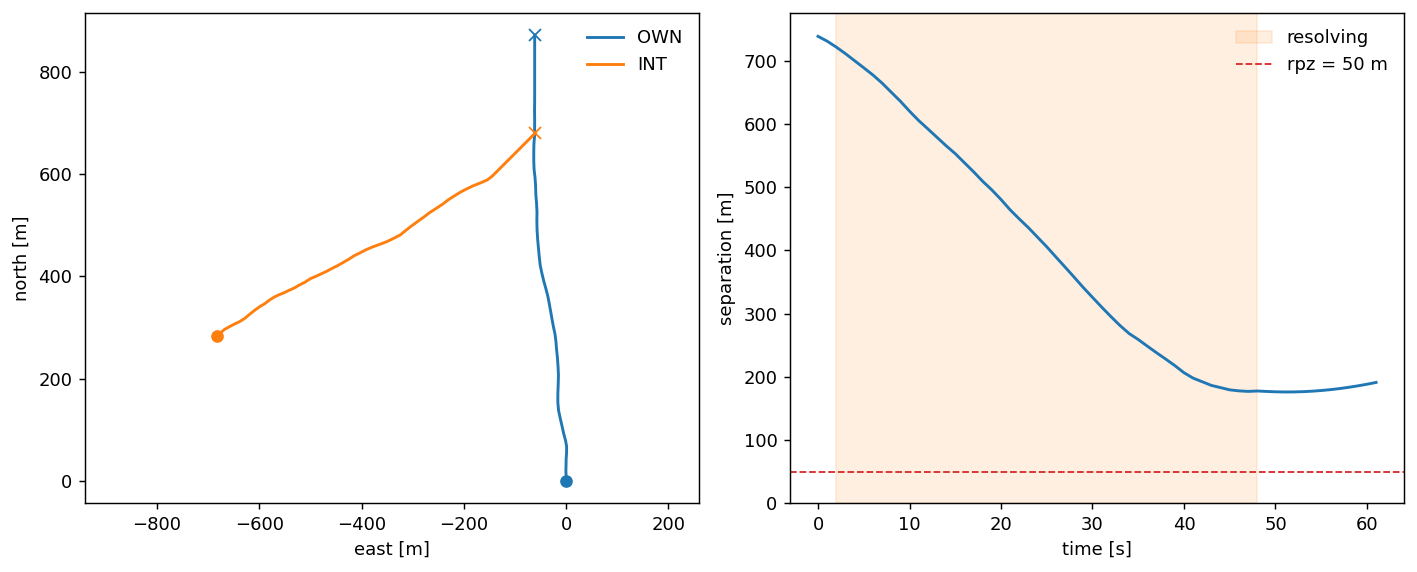

In [4]:
noisy_own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                            pos_ci95=20.0, vel_ci95=2.0)
noisy_intr = create_conflict(noisy_own, intr_id="INT", dpsi=45.0, dcpa=0.0, tlos=90.0, rpz=RPZ)

# every random run needs a stream of random numbers; this one comes from a seed, so it repeats
nav_stream, _, _ = spawn(root_seed_sequence(seed=0), 3)

noisy = run_fleet(
    [Agent(noisy_own, M600), Agent(noisy_intr, M600)],
    rpz=RPZ, t_lookahead=120.0, dt=1.0,
    detector=StateBased(), resolver=MVP(margin=1.05), recovery=PastCPA(),
    navigation=GnssNavigation(),          # <- the new part
    rng=generator(nav_stream),
    t_max=600.0, record=True,
)

print(f"perfect information:  closest approach {outcome.min_sep:6.1f} m,  separation lost: {outcome.los}")
print(f"with sensor error:    closest approach {noisy.min_sep:6.1f} m,  separation lost: {noisy.los}")

fig = plot_pairwise(noisy, rpz=RPZ)

Same geometry, same algorithms, a different answer. Each aircraft is now steering from a position
that jumps around by a few metres every second, so it keeps slightly re-aiming.

## Step 3: one run tells you almost nothing

Here is what trips people up. That run used one particular set of random errors. A different set
gives a different closest approach. So a single run cannot tell you whether the software is safe —
it tells you what happened *once*.

Watch what happens when we change nothing but the seed:

In [5]:
def one_encounter(seed: int) -> float:
    nav, _, _ = spawn(root_seed_sequence(seed), 3)
    o = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                        pos_ci95=20.0, vel_ci95=2.0)
    i = create_conflict(o, intr_id="INT", dpsi=45.0, dcpa=0.0, tlos=90.0, rpz=RPZ)
    return run_fleet([Agent(o, M600), Agent(i, M600)], rpz=RPZ, t_lookahead=120.0, dt=1.0,
                     detector=StateBased(), resolver=MVP(margin=1.05), recovery=PastCPA(),
                     navigation=GnssNavigation(), rng=generator(nav),
                     t_max=600.0).min_sep

for seed in range(8):
    print(f"seed {seed}: closest approach {one_encounter(seed):6.1f} m")

seed 0: closest approach  175.9 m
seed 1: closest approach  231.2 m
seed 2: closest approach   78.8 m
seed 3: closest approach  161.2 m
seed 4: closest approach   98.0 m
seed 5: closest approach  104.0 m


seed 6: closest approach  265.8 m
seed 7: closest approach  272.3 m


Same situation, eight answers. "Is this safe?" has no meaning for a single run; it only means
something for the *spread* of runs.

So the real question becomes: **across many encounters, in what fraction is separation lost?**

## Step 4: many encounters

`estimate_ipr` does exactly that. It samples encounters, runs each one, and counts.

One detail worth knowing early: it does not repeat the *same* encounter. It draws a fresh one each
time — crossing angle, miss distance, and which side the intruder passes are all randomised unless
you pin them. Below we pin the angle at 45° so we are asking about one geometry, and let the rest
vary.

We also turn the sensor error up to 80 m. That is a poor fix by any standard, chosen so failures are
frequent enough to count in a reasonable number of runs.

In [6]:
base = load_config("../../configs/pairwise.yaml")     # sensible defaults for everything else
cfg = dataclasses.replace(
    base, seed=0, n_encounters=3000,
    scenario=dataclasses.replace(base.scenario, speed=10.0, tlos=60.0,
                                 pos_ci95=80.0, vel_ci95=2.0),
)

result = estimate_ipr(
    cfg, M600,
    StateBased(), MVP(margin=1.05), PastCPA(),
    GnssNavigation(),
    dpsi=45.0, dcpa=0.0,          # pin the geometry
)

lo, hi = result.ci95
print(f"encounters run:        {result.n_encounters}")
print(f"separation lost in:    {result.n_los}")
print(f"so P(loss)  =          {result.p_los:.4f}")
print(f"95% confident it is between {lo:.4f} and {hi:.4f}")

encounters run:        3000
separation lost in:    198
so P(loss)  =          0.0660
95% confident it is between 0.0577 and 0.0755


That last line is the important one, and it is where most misreadings start.

**The number is an estimate, not the truth.** We ran 3000 encounters and lost separation in some of
them; a different 3000 would give a slightly different count. The interval says where the real value
plausibly sits. Quote the estimate without it and you are claiming a precision you do not have.

### How many runs is enough?

There is no fixed answer — it depends how small the probability is and how precisely you need it.
But you can watch it settle. The estimator keeps every encounter's closest approach, so we can ask
what the answer *would* have been after 25 runs, 50, 100, and so on, without running anything again:

  after  estimate           95% interval
     25    0.0800   [0.0222, 0.2497]
     50    0.0800   [0.0315, 0.1884]
    100    0.0900   [0.0481, 0.1623]
    200    0.0900   [0.0577, 0.1378]
    400    0.0725   [0.0510, 0.1022]
    800    0.0700   [0.0543, 0.0898]
   1600    0.0681   [0.0568, 0.0815]
   3000    0.0660   [0.0577, 0.0755]


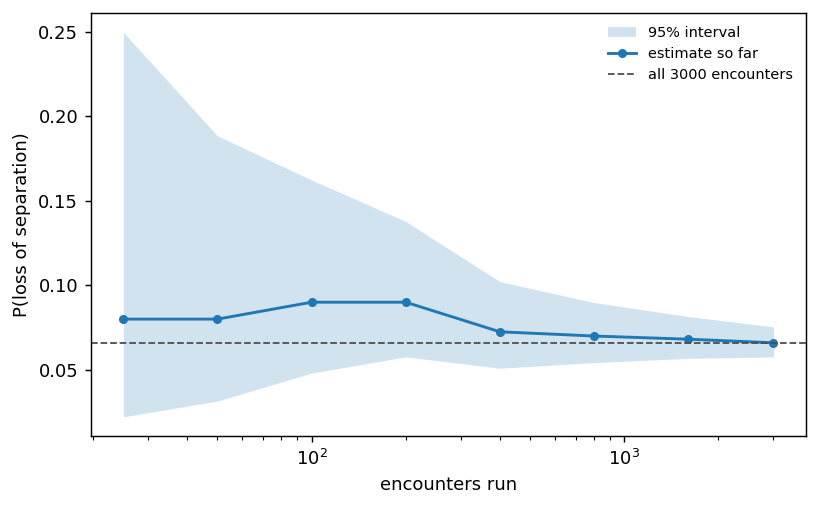

In [7]:
seps = np.array(result.min_seps)           # one closest-approach per encounter
ns = [25, 50, 100, 200, 400, 800, 1600, 3000]

est, band_lo, band_hi = [], [], []
for n in ns:
    k = int((seps[:n] < RPZ).sum())        # losses among the first n encounters
    a, b = wilson_interval(k, n)
    est.append(k / n); band_lo.append(a); band_hi.append(b)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.fill_between(ns, band_lo, band_hi, alpha=0.2, color="#1f77b4", lw=0, label="95% interval")
ax.plot(ns, est, marker="o", ms=4, lw=1.6, color="#1f77b4", label="estimate so far")
ax.axhline(result.p_los, color="0.3", lw=1.0, ls="--", label="all 3000 encounters")
ax.set_xscale("log")
ax.set_xlabel("encounters run")
ax.set_ylabel("P(loss of separation)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

print(f"{'after':>7} {'estimate':>9}   {'95% interval':>20}")
for n, e, a, b in zip(ns, est, band_lo, band_hi):
    print(f"{n:>7} {e:>9.4f}   [{a:.4f}, {b:.4f}]")

The estimate wanders early and settles late, and the shaded band — how sure we are — narrows the
whole way.

Look at the first row before trusting any small experiment. After 25 encounters the interval runs
from about 0.02 to 0.25: an order of magnitude, which rules out essentially nothing. The band
narrows with the *square root* of the number of runs, and that is the bad news hiding in this plot —
**to halve your uncertainty you need four times the runs.**

## Step 5: asking a question

So far we have measured one situation. An experiment asks how the answer *changes* when something
changes, and that is what `run_experiment` is for.

You describe what varies: `Fixed` holds a parameter still, `Sweep` varies it. Every swept parameter
becomes a column in the results, and you get one row per combination.

Let us ask a real question: **how much does position accuracy matter?**

In [8]:
study = run_experiment(
    {
        "pos_ci95": Sweep([0.0, 20.0, 40.0, 60.0, 80.0, 100.0]),   # the question
        "vel_ci95": Fixed(2.0),                                    # everything else held still
        "dpsi": Fixed(45.0),
        "dcpa": Fixed(0.0),
        "tlos": Fixed(60.0),
        "speed": Fixed(10.0),
    },
    methods=Methods(
        detector=StateBased(), resolver=MVP(margin=1.05), recovery=PastCPA(),
        navigation=GnssNavigation(),     # needed, or pos_ci95 would do nothing
        perf=M600,
    ),
    backend=MC(n_encounters=1000),       # 1000 encounters per row
    base_config=cfg,
    seed=0,
    n_jobs=4,                            # spread across 4 cores
)

study

,pos_ci95,p_los,p_los_lo,p_los_hi,ipr,median_min_sep,n_los,n_encounters,detection_rate
0,0.0,0.001,0.000177,0.005643,0.999,123.939907,1,1000,1.0
1,20.0,0.002,0.000549,0.007263,0.998,125.425609,2,1000,1.0
2,40.0,0.003,0.001021,0.008783,0.997,128.946428,3,1000,1.0
3,60.0,0.028,0.019442,0.040170,0.972,129.564408,28,1000,1.0
4,80.0,0.065,0.051324,0.082006,0.935,129.313571,65,1000,1.0
5,100.0,0.137,0.117073,0.159706,0.863,125.504656,137,1000,1.0


Six rows, one per accuracy level. `p_los` is the answer, `p_los_lo` and `p_los_hi` bracket it, and
`n_los` is the raw count they came from.

Plotted, the shape is much clearer:

pos_ci95     0 m   P(loss) 0.0010   [0.0002, 0.0056]
pos_ci95    20 m   P(loss) 0.0020   [0.0005, 0.0073]
pos_ci95    40 m   P(loss) 0.0030   [0.0010, 0.0088]
pos_ci95    60 m   P(loss) 0.0280   [0.0194, 0.0402]
pos_ci95    80 m   P(loss) 0.0650   [0.0513, 0.0820]
pos_ci95   100 m   P(loss) 0.1370   [0.1171, 0.1597]


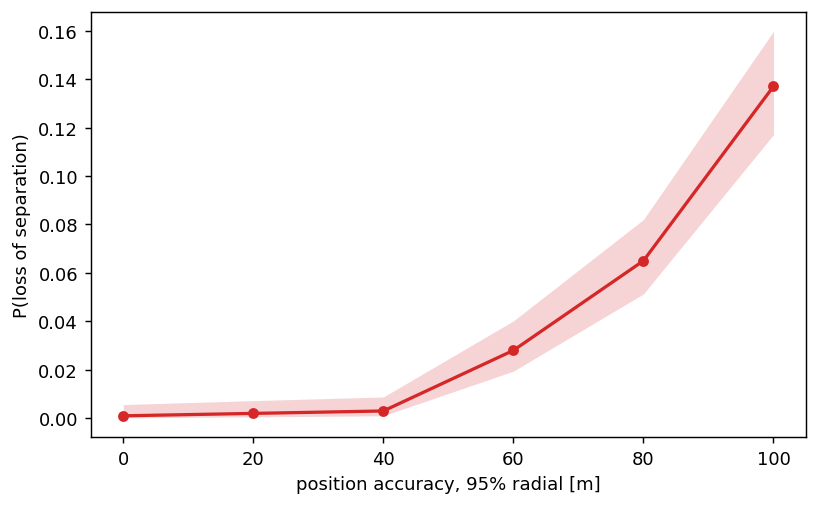

In [9]:
rows = study.records()
x = [r["pos_ci95"] for r in rows]

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.fill_between(x, [r["p_los_lo"] for r in rows], [r["p_los_hi"] for r in rows],
                alpha=0.2, color="#d62728", lw=0)
ax.plot(x, [r["p_los"] for r in rows], marker="o", ms=5, lw=1.8, color="#d62728")
ax.set_xlabel("position accuracy, 95% radial [m]")
ax.set_ylabel("P(loss of separation)")
fig.tight_layout()

for r in rows:
    print(f"pos_ci95 {r['pos_ci95']:>5.0f} m   P(loss) {r['p_los']:.4f}   "
          f"[{r['p_los_lo']:.4f}, {r['p_los_hi']:.4f}]")

This is not a straight line, and the shape is the finding. Up to about 40 m the failure rate barely
moves — the avoidance logic absorbs the error. Past that it climbs steeply, and by 100 m it is more
than a hundred times the clean rate. There is a knee, and it is worth knowing where yours is.

Two honest caveats about reading this plot:

- **The leftmost point is not zero.** At `pos_ci95 = 0` the position is exact, but we held
  `vel_ci95` at 2.0, so the aircraft are still wrong about each other's *velocity*. That residual is
  the whole reason the curve does not start at zero.
- **The first three points are not really distinguishable.** Their intervals overlap heavily — with
  1000 encounters and one to three failures, this experiment can say "rare" but cannot rank them.
  Concluding that 40 m is worse than 20 m would be reading noise.

## Step 6: the rate is not the whole story

Here is something a failure rate cannot tell you. The library also reports the **median closest
approach**: in a typical encounter, how much room was actually left. It comes free, because every
encounter's closest approach is kept.

Put the two side by side and something uncomfortable shows up.

pos_ci95     0 m   P(loss) 0.0010   median closest approach  123.9 m
pos_ci95    20 m   P(loss) 0.0020   median closest approach  125.4 m
pos_ci95    40 m   P(loss) 0.0030   median closest approach  128.9 m
pos_ci95    60 m   P(loss) 0.0280   median closest approach  129.6 m
pos_ci95    80 m   P(loss) 0.0650   median closest approach  129.3 m
pos_ci95   100 m   P(loss) 0.1370   median closest approach  125.5 m


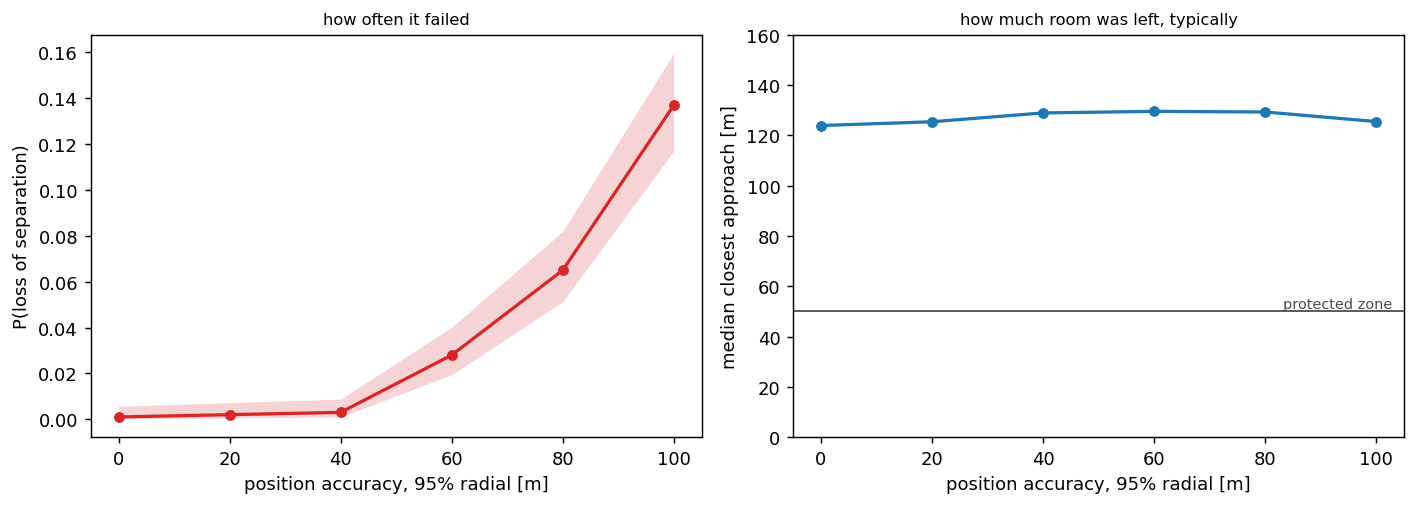

In [10]:
fig, (ax_p, ax_m) = plt.subplots(1, 2, figsize=(11.0, 4.0))

ax_p.plot(x, [r["p_los"] for r in rows], marker="o", ms=5, lw=1.8, color="#d62728")
ax_p.fill_between(x, [r["p_los_lo"] for r in rows], [r["p_los_hi"] for r in rows],
                  alpha=0.2, color="#d62728", lw=0)
ax_p.set_ylabel("P(loss of separation)")
ax_p.set_title("how often it failed", fontsize=9)

ax_m.plot(x, [r["median_min_sep"] for r in rows], marker="o", ms=5, lw=1.8, color="#1f77b4")
ax_m.axhline(RPZ, color="0.3", lw=1.0)
ax_m.annotate("protected zone", (0.98, RPZ), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color="0.3")
ax_m.set_ylim(0, 160)
ax_m.set_ylabel("median closest approach [m]")
ax_m.set_title("how much room was left, typically", fontsize=9)

for ax in (ax_p, ax_m):
    ax.set_xlabel("position accuracy, 95% radial [m]")
fig.tight_layout()

for r in rows:
    print(f"pos_ci95 {r['pos_ci95']:>5.0f} m   P(loss) {r['p_los']:.4f}   "
          f"median closest approach {r['median_min_sep']:6.1f} m")

**The right-hand panel is flat.** The typical encounter clears by about 125 m at every accuracy
level, comfortably outside the protected zone, and looks equally healthy at 100 m of sensor error as
at none. Meanwhile the left panel has climbed by a factor of a hundred.

That contrast is the most useful thing in this tutorial. **The typical case told you nothing about
the failures.** Failures do not happen because the average encounter drifted closer; they happen to
a minority of unlucky encounters while the bulk of the distribution stays put. Anyone watching only
the typical behaviour of this system would have seen a perfectly steady picture right up until the
accidents started.

This is why the two numbers answer different questions, and why safety is a question about the worst
few percent rather than the middle.

## Step 7: the record behind the table

The table is a summary. Underneath it, every encounter is still there, and `study.cell(...)` reaches
the row's raw record — so a question you think of later is a lookup rather than another run:

at pos_ci95 = 100 m, over 1000 encounters:
  came within 50 m   0.1370   <- this is p_los
  came within 25 m   0.0810
  came within 10 m   0.0350
  closest of all     0.1 m

      quantile    pos_ci95=0    pos_ci95=100
       1st pct        53.0 m           3.0 m
       5th pct        58.9 m          15.5 m
lower quartile        87.2 m          82.8 m
        median       123.9 m         125.5 m
upper quartile       165.9 m         156.5 m


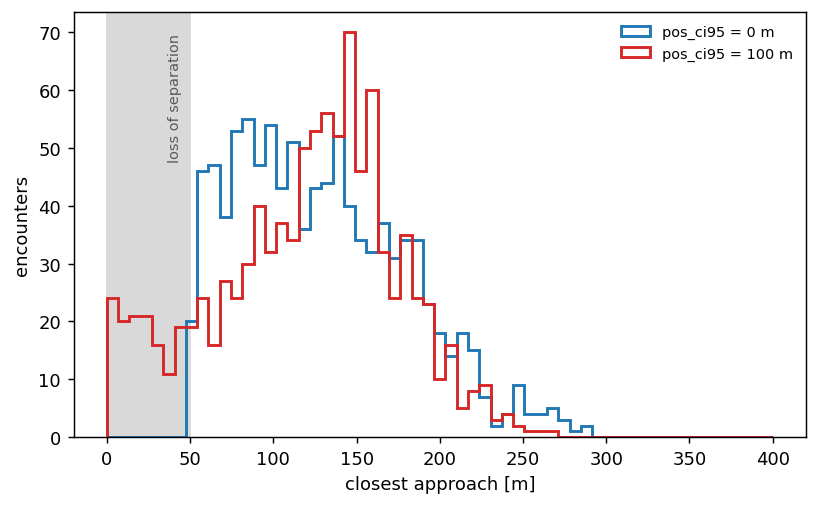

In [11]:
worst = study.cell(pos_ci95=100.0)
s = np.array(worst.min_seps)

print(f"at pos_ci95 = 100 m, over {len(s)} encounters:")
print(f"  came within {RPZ:.0f} m   {(s < RPZ).mean():.4f}   <- this is p_los")
print(f"  came within 25 m   {(s < 25).mean():.4f}")
print(f"  came within 10 m   {(s < 10).mean():.4f}")
print(f"  closest of all     {s.min():.1f} m")

# where do the clean and noisy cases actually differ? compare them quantile by quantile
clean = np.array(study.cell(pos_ci95=0.0).min_seps)
print(f"\n{'quantile':>14} {'pos_ci95=0':>13} {'pos_ci95=100':>15}")
for q, label in ((1, "1st pct"), (5, "5th pct"), (25, "lower quartile"),
                 (50, "median"), (75, "upper quartile")):
    print(f"{label:>14} {np.percentile(clean, q):>11.1f} m {np.percentile(s, q):>13.1f} m")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for r, colour in ((0.0, "#1f77b4"), (100.0, "#d62728")):
    d = np.array(study.cell(pos_ci95=r).min_seps)
    ax.hist(d, bins=np.linspace(0, 400, 60), histtype="step", lw=1.6,
            color=colour, label=f"pos_ci95 = {r:.0f} m")
ax.axvspan(0, RPZ, color="0.85", zorder=0)
ax.annotate("loss of separation", (RPZ * 0.9, 0.95), xycoords=("data", "axes fraction"),
            ha="right", va="top", fontsize=8, color="0.35", rotation=90)
ax.set_xlabel("closest approach [m]")
ax.set_ylabel("encounters")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

The quantile table and the histogram tell the same story, and it is worth reading carefully.

Look at where the two columns agree. The medians are 124 m and 126 m, and the two quartiles differ
by under 10 m. **The middle half of the two distributions is essentially the same.** Now look at the
bottom: the 5th percentile drops from 59 m to 16 m, and the 1st from 53 m to 3 m. The clean case
never came closer than 49 m; the noisy one has an encounter that came within a few centimetres.

The histogram shows why. The clean distribution has a wall at the protected zone — apart from a
single encounter in a thousand it does not extend left of 50 m at all, because with good information
the resolver holds that line. The noisy distribution has no wall. Its bulk sits in the same place,
but a slice of it has spilled straight across the boundary into the shaded region.

That spill is the entire difference in safety between the two settings, and no summary of the middle
of the distribution — mean, median, or quartile — would have revealed it.

None of these numbers cost a single new simulation. They were all already in the run.

## Step 8: the answer has to be reproducible

Every number above is fixed by the configuration, the seed, and the version of the library — nothing
else. Run it again on another machine and you get the same answer.

Two switches are worth knowing:

- **`cache=True`** stores each row, so re-running is instant and extending a study only runs the new
  rows. It is keyed on everything that affects the numbers, so it can save time but never change an
  answer.
- **`card_dir=...`** writes a small text file recording what was run: the declaration, the
  algorithms, the seed, and a fingerprint of the library source.

## What you have learned

1. One encounter is an anecdote. Safety is a probability, so you need many.
2. Every estimate needs an interval. A rate quoted without one overstates what you know.
3. Halving the uncertainty costs four times the runs.
4. `Fixed` holds a parameter, `Sweep` varies it, and you get one row per combination.
5. The typical case can stay perfectly steady while the failure rate rises a hundredfold. Watch the
   tail, not the middle.
6. The per-encounter record is kept, so later questions are lookups rather than re-runs.

## Where to go next

- **Change an algorithm.** `MVP` is one of two avoidance methods that ship — swap in `VO(1.05)` and
  compare the curves. Any piece of the stack can be replaced with your own by subclassing one class.
- **Add more uncertainty.** A radio link that drops messages, a wind field, transmitters that fall
  out of sync. All are declared the same way `pos_ci95` was here.
- **Chase a rarer failure.** Counting stops working when failures are very rare: a rate of one in a
  million needs millions of runs. A second estimator, `IPS`, gets there far more cheaply by
  concentrating effort on the encounters heading for trouble — and it reads the *same* declaration.
  Everything you wrote above stays as it is; you swap `backend=MC(...)` for `backend=IPS(...)` and
  give the new backend its own settings, chiefly a ladder of separations to aim at in turn.

The full handbook is at [opencdarr.github.io](https://opencdarr.github.io).